In [ ]:
# In Colab cell:
!pip install plotly
!apt-get install ffmpeg  # For MP4 animations (optional)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.



THE ARITHMETIC SINGULARITY - COMPLETE ANALYSIS

[PART 1] QUANTITATIVE METRICS
----------------------------------------------------------------------
SPIRAL PATTERN ANALYSIS
N = 30000, Primes = 3245

Angular Autocorr Strength: 3.5431
Angular Clustering (CV):   1.1249
Spatial Correlation:       0.5042

OVERALL STRUCTURE SCORE:   11.4215
SPIRAL PATTERN ANALYSIS
N = 30000, Primes = 3245

Angular Autocorr Strength: 0.7159
Angular Clustering (CV):   1.3135
Spatial Correlation:       0.5043

OVERALL STRUCTURE SCORE:   6.0360

✓ Saved: comparison_sqrt_vs_n2log.png

[PART 2] 3D STATIC VISUALIZATIONS
----------------------------------------------------------------------

[1/4] Creating 3D spiral of all integers...


/tmp/ipykernel_1602/2509711816.py:386: UserWarning: Attempting to set identical low and high zlims makes transformation singular; automatically expanding.
  ax.set_zlim([0, np.max(z) * 1.1])


  ✓ Saved: 3d_singularity_all_integers.png

[2/4] Creating 3D spiral of primes only...
  ✓ Saved: 3d_singularity_primes_only.png

[3/4] Creating side-by-side comparison...


/tmp/ipykernel_1602/2509711816.py:428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  ✓ Saved: 3d_dual_comparison.png

[4/4] Creating event horizon visualization...
  ✓ Saved: 3d_event_horizon.png

STATIC VISUALIZATIONS COMPLETE!


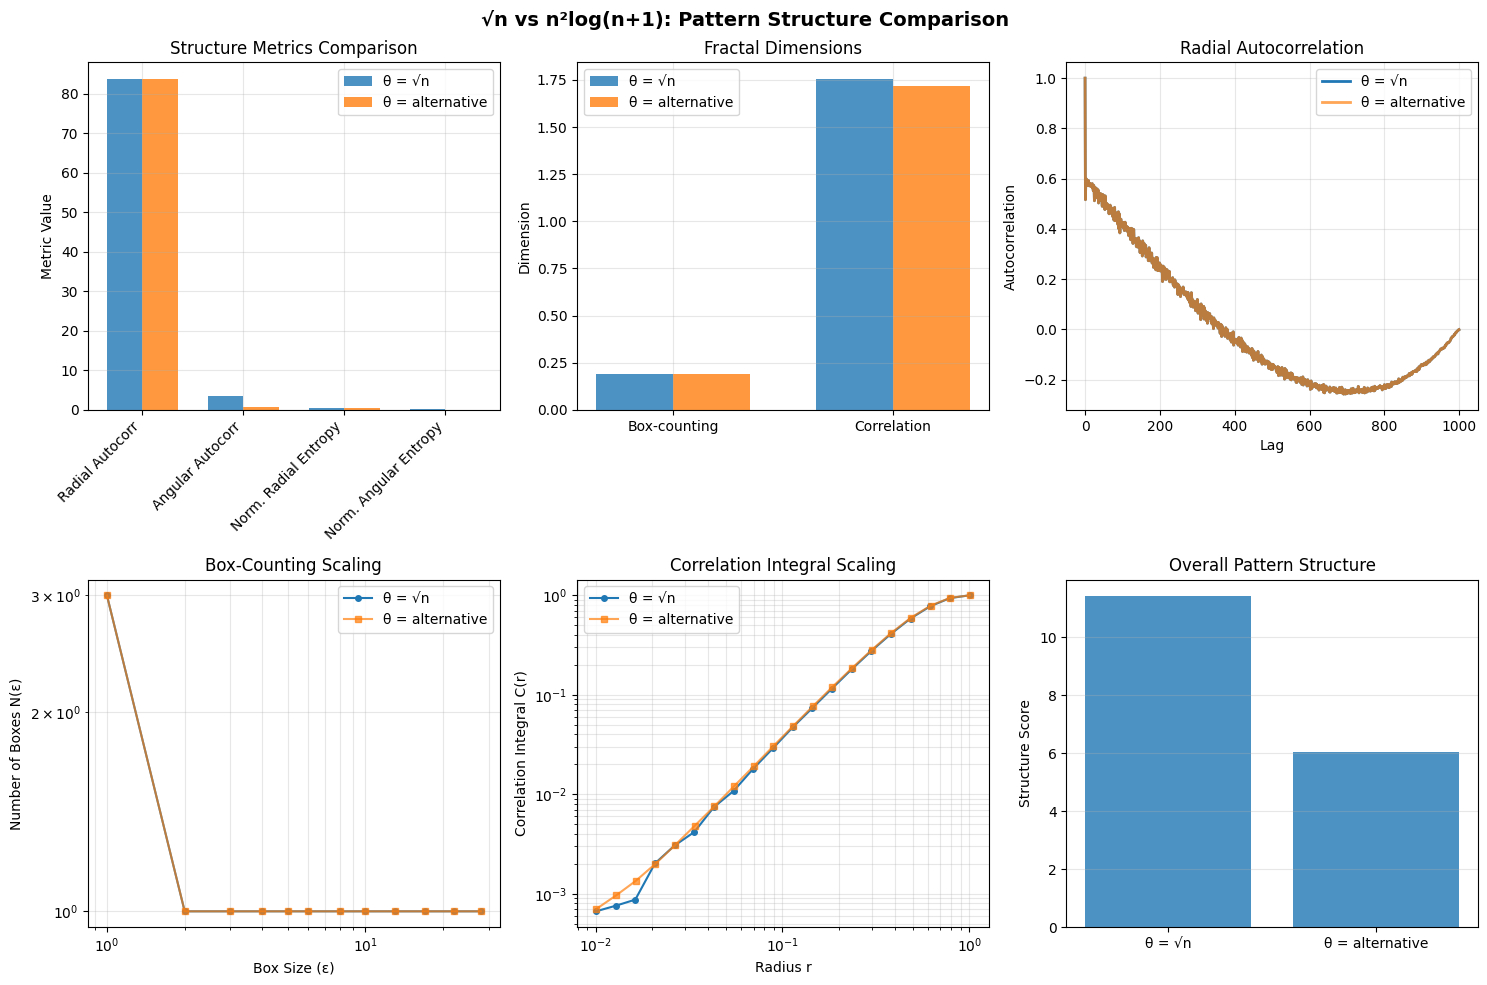

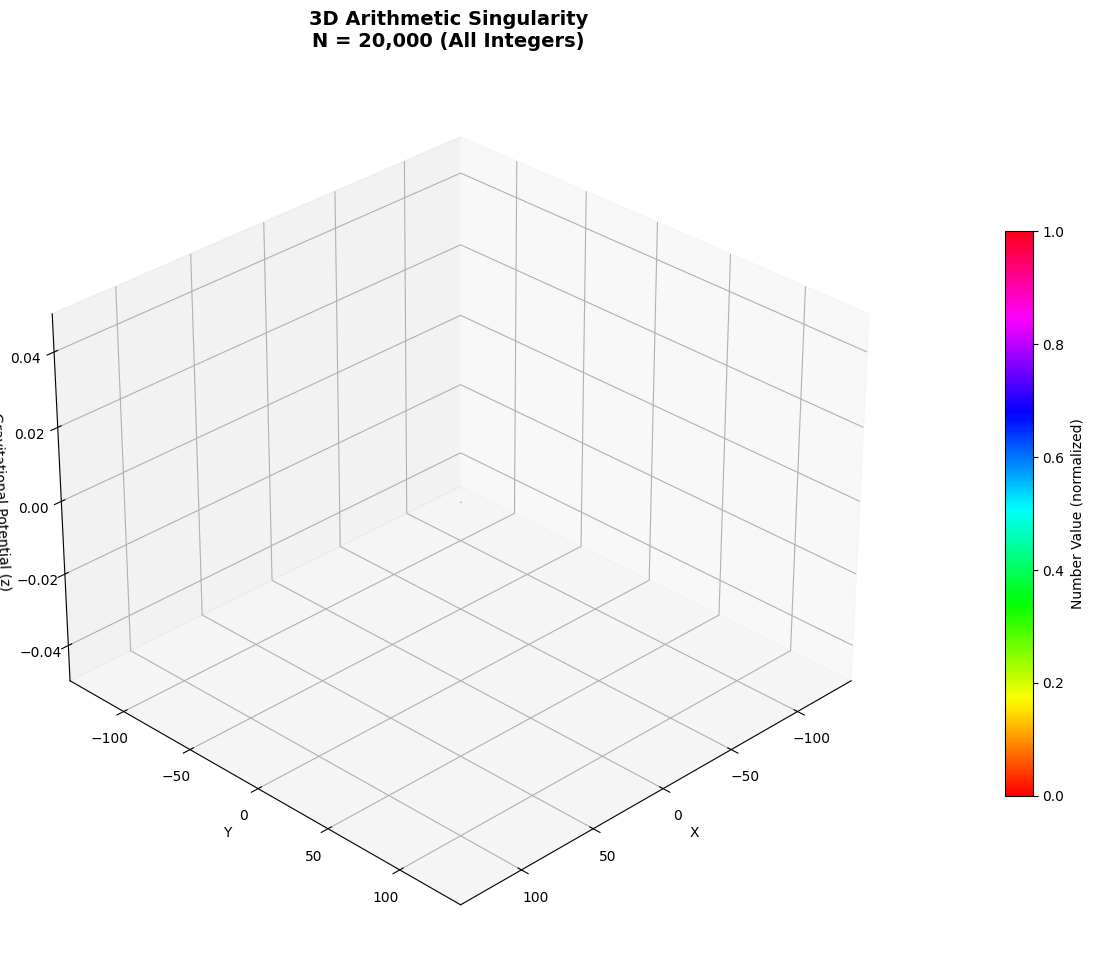

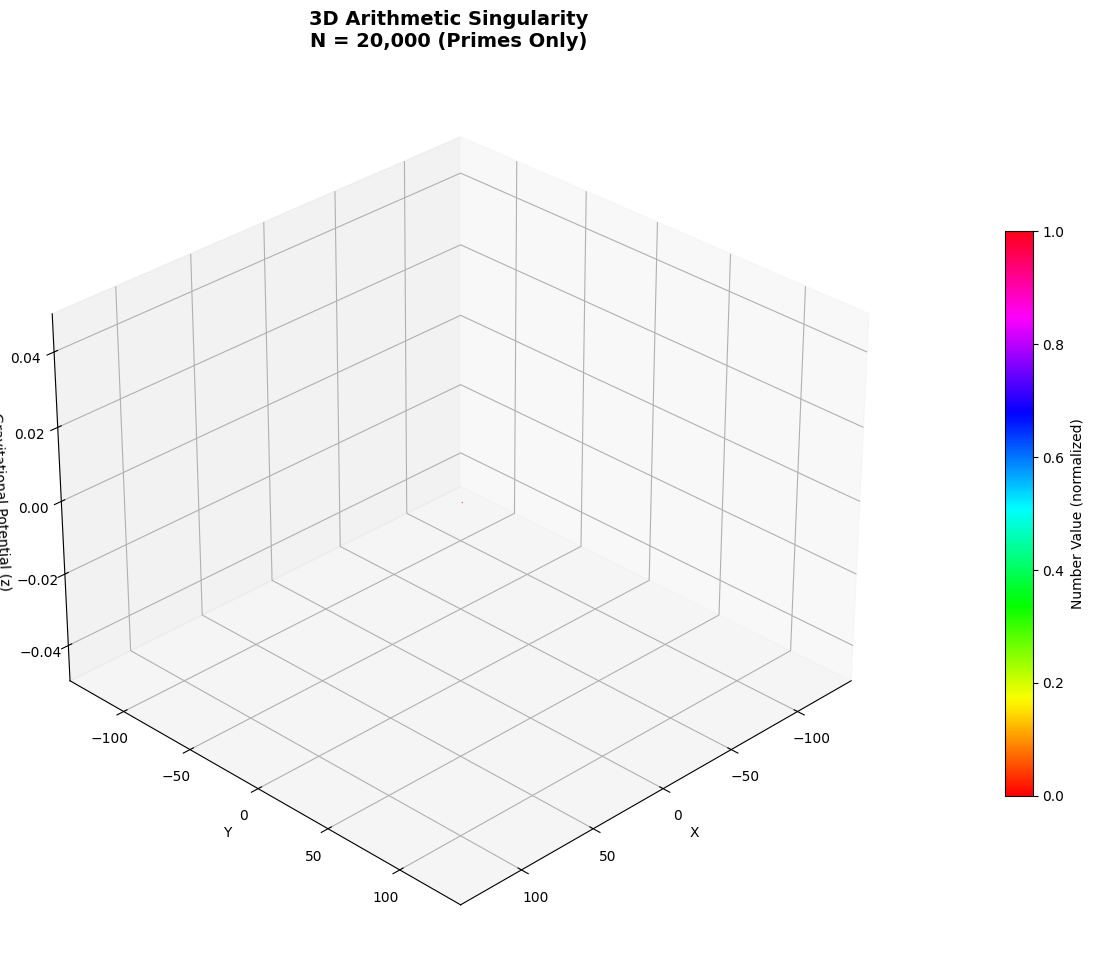

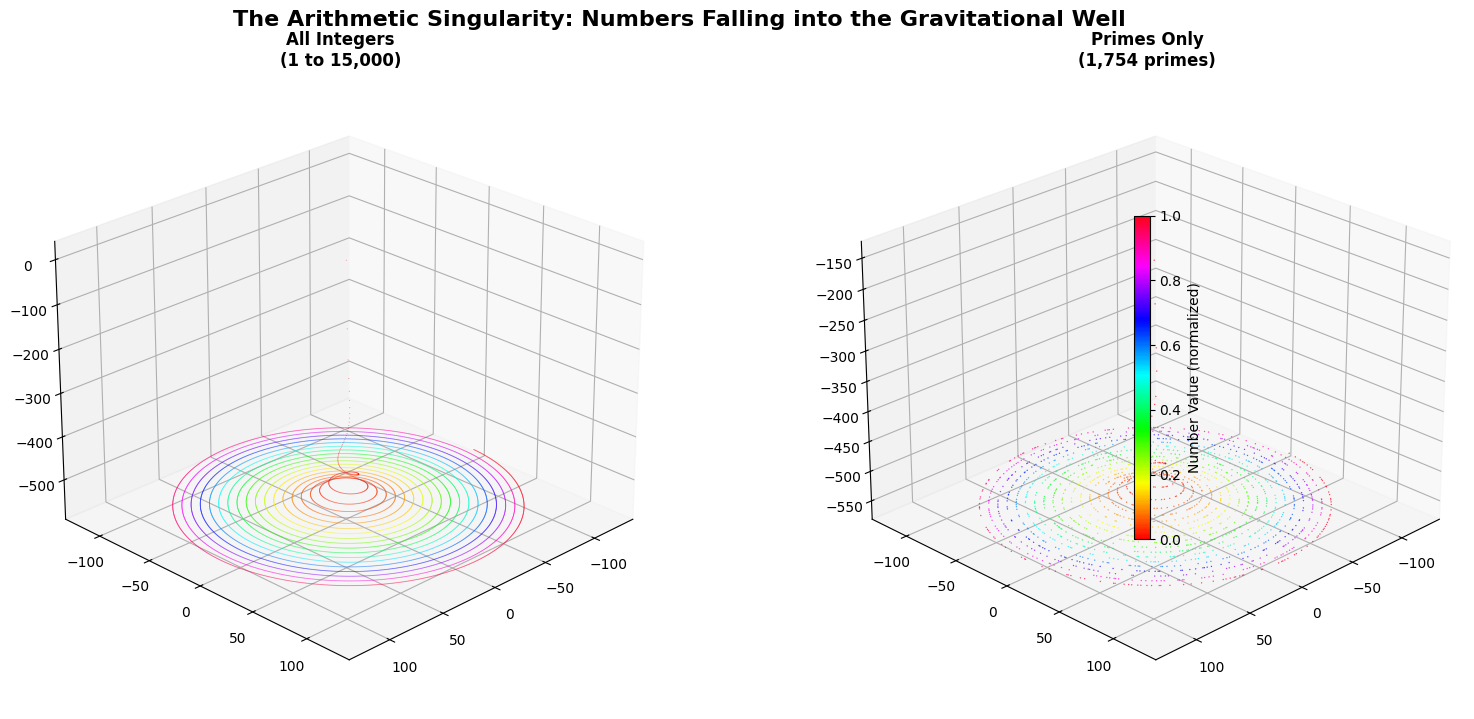

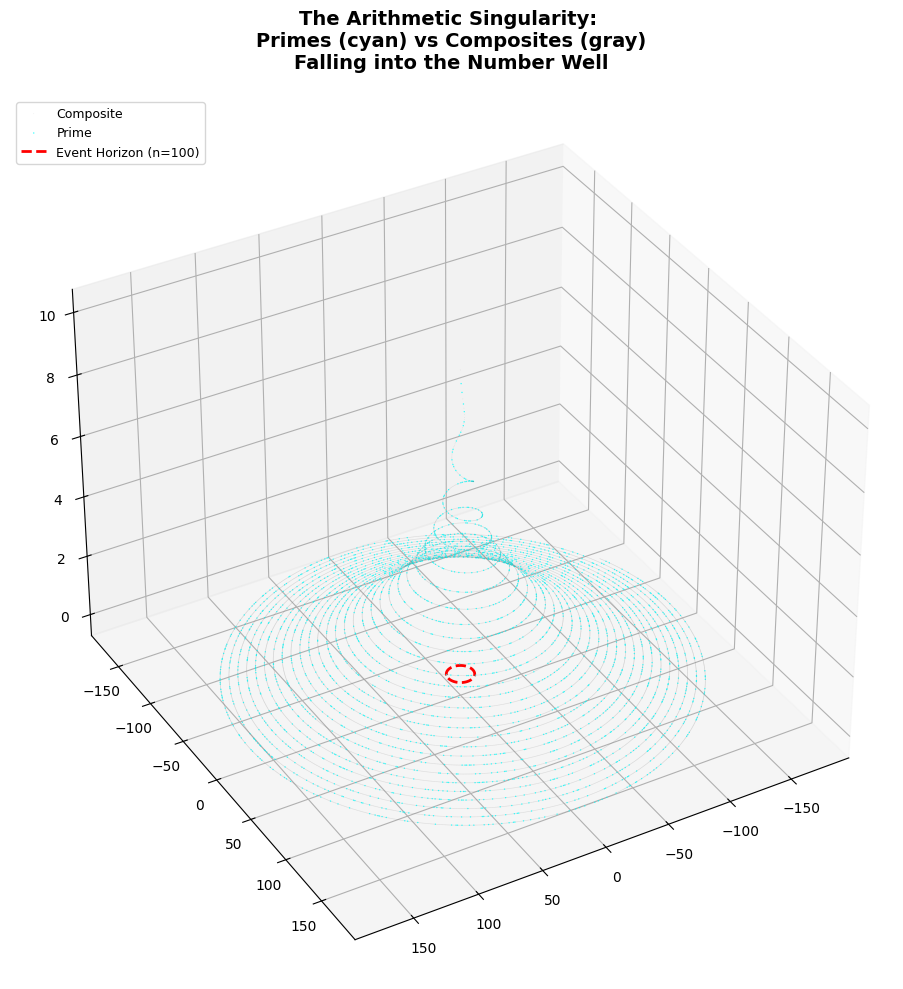


GENERATING ANIMATIONS (Frame-by-Frame Method)

[1/2] All integers animation...
    Generating 72 frames...


/tmp/ipykernel_1602/2509711816.py:516: UserWarning: Attempting to set identical low and high zlims makes transformation singular; automatically expanding.
  ax.set_zlim([0, np.max(z) * 1.1])


      Progress: 12/72 frames
      Progress: 24/72 frames
      Progress: 36/72 frames
      Progress: 48/72 frames
      Progress: 60/72 frames
      Progress: 72/72 frames
  ✓ All frames saved to singularity_all_frames/
    Converting frames to GIF...
  ✓ Saved: singularity_all_rotation.gif
    Converting frames to MP4...


  ⚠ MP4 conversion failed: All images in a movie should have same size
  Install with: pip install imageio-ffmpeg

  ✓ Animation complete!

[2/2] Primes only animation...
    Generating 72 frames...
      Progress: 12/72 frames
      Progress: 24/72 frames
      Progress: 36/72 frames
      Progress: 48/72 frames
      Progress: 60/72 frames
      Progress: 72/72 frames
  ✓ All frames saved to singularity_primes_frames/
    Converting frames to GIF...
  ✓ Saved: singularity_primes_rotation.gif
    Converting frames to MP4...


  ⚠ MP4 conversion failed: All images in a movie should have same size
  Install with: pip install imageio-ffmpeg

  ✓ Animation complete!

ANIMATIONS COMPLETE!

📁 Files generated:
  • singularity_all_rotation.gif
  • singularity_all_rotation.mp4
  • singularity_primes_rotation.gif
  • singularity_primes_rotation.mp4

💡 Upload GIFs to LinkedIn/Twitter/GitHub!

GENERATING INTERACTIVE HTML VISUALIZATIONS

[1/2] All integers interactive...
  ✓ Saved: interactive_singularity_all.html

[2/2] Primes only interactive...
  ✓ Saved: interactive_singularity_primes.html

INTERACTIVE HTML COMPLETE!

📁 Files generated:
  • interactive_singularity_all.html
  • interactive_singularity_primes.html

💡 Open in browser or upload to GitHub Pages!

🎉 ALL VISUALIZATIONS COMPLETE! 🎉

📁 FINAL FILE LIST:

  Quantitative Analysis:
    • comparison_sqrt_vs_n2log.png

  Static 3D Images:
    • 3d_singularity_all_integers.png
    • 3d_singularity_primes_only.png
    • 3d_dual_comparison.png
    • 3d_event_horizon.

In [ ]:
"""
spiral_pattern_analysis.py
==========================
Quantitative metrics for analyzing pattern structure in number spirals.
Includes: Analysis, 3D Visualizations, Animations, and Interactive HTML.

Author: Néstor E. Ramos
For: "The Arithmetic Singularity: Why Prime Patterns Suggest Finite Recursion"
"""

# =============================================================================
# ALL IMPORTS
# =============================================================================

import numpy as np
from scipy import fft
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from matplotlib.cm import hsv
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d import Axes3D
from typing import Tuple, List, Dict
import warnings
import os
import glob

# =============================================================================
# MAIN ANALYSIS CLASS
# =============================================================================

class SpiralPatternAnalyzer:
    """Quantitative analysis of pattern structure in polar number spirals."""

    def __init__(self, n_max: int = 30000, theta_function=None):
        self.n_max = n_max
        self.theta_func = theta_function if theta_function else lambda n: np.sqrt(n)

        self.numbers = np.arange(1, n_max + 1)
        self.radii = np.sqrt(self.numbers)
        self.angles = self.theta_func(self.numbers)

        self.x = self.radii * np.cos(self.angles)
        self.y = self.radii * np.sin(self.angles)

        self.is_prime = self._sieve_of_eratosthenes(n_max)
        self.is_prime = self.is_prime[1:]
        self.primes = self.numbers[self.is_prime]

        self.prime_x = self.x[self.is_prime]
        self.prime_y = self.y[self.is_prime]

    def _sieve_of_eratosthenes(self, n: int) -> np.ndarray:
        sieve = np.ones(n + 1, dtype=bool)
        sieve[0:2] = False
        for i in range(2, int(n**0.5) + 1):
            if sieve[i]:
                sieve[i*i:n+1:i] = False
        return sieve

    def compute_radial_autocorrelation(self, n_bins: int = 1000, normalize: bool = True) -> Tuple[np.ndarray, np.ndarray]:
        max_radius = np.max(self.radii)
        bin_edges = np.linspace(0, max_radius, n_bins + 1)
        prime_radial_hist, _ = np.histogram(self.radii[self.is_prime], bins=bin_edges)

        signal_data = prime_radial_hist
        if normalize:
            signal_data = (signal_data - np.mean(signal_data)) / np.std(signal_data)

        fft_signal = fft.fft(signal_data, n=2*len(signal_data))
        autocorr_full = fft.ifft(fft_signal * np.conj(fft_signal)).real
        autocorr = autocorr_full[:len(signal_data)]
        if normalize:
            autocorr = autocorr / len(signal_data)

        return np.arange(len(autocorr)), autocorr

    def compute_angular_autocorrelation(self, n_bins: int = 360, normalize: bool = True) -> Tuple[np.ndarray, np.ndarray]:
        bin_edges = np.linspace(0, 2*np.pi, n_bins + 1)
        prime_angular_hist, _ = np.histogram(self.angles[self.is_prime], bins=bin_edges)

        signal_data = prime_angular_hist
        if normalize:
            signal_data = (signal_data - np.mean(signal_data)) / np.std(signal_data)

        fft_signal = fft.fft(signal_data, n=2*len(signal_data))
        autocorr_full = fft.ifft(fft_signal * np.conj(fft_signal)).real
        autocorr = autocorr_full[:len(signal_data)]
        if normalize:
            autocorr = autocorr / len(signal_data)

        return np.arange(len(autocorr)), autocorr

    def autocorrelation_strength(self, lags: np.ndarray, autocorr: np.ndarray, max_lag_fraction: float = 0.2) -> float:
        max_lag = int(len(lags) * max_lag_fraction)
        autocorr_normalized = autocorr[:max_lag] / autocorr[0]
        return np.trapezoid(np.abs(autocorr_normalized), dx=1)

    def box_counting_dimension(self, scales: List[int] = None, n_scales: int = 15) -> Tuple[np.ndarray, np.ndarray, float]:
        points = np.column_stack([self.prime_x, self.prime_y])
        points_norm = (points - points.min(axis=0)) / np.ptp(points, axis=0)

        if scales is None:
            max_scale = int(np.sqrt(len(points)) / 2)
            scales = np.unique(np.logspace(0, np.log10(max_scale), n_scales).astype(int))

        counts = []
        for box_size in scales:
            if box_size <= 0:
                counts.append(len(points))
                continue
            discrete = np.floor(points_norm * (1.0 / box_size)).astype(int)
            counts.append(len(np.unique(discrete, axis=0)))

        counts = np.array(counts)
        valid = (counts > 0) & (np.array(scales) > 0)
        if np.sum(valid) < 3:
            return np.array(scales), counts, np.nan

        slope, _ = np.polyfit(np.log(1.0 / np.array(scales)[valid]), np.log(counts[valid]), 1)
        return np.array(scales), counts, slope

    def correlation_dimension(self, n_points: int = 5000, radii: np.ndarray = None, n_radii: int = 20) -> Tuple[np.ndarray, np.ndarray, float]:
        if len(self.prime_x) > n_points:
            indices = np.random.choice(len(self.prime_x), n_points, replace=False)
            points = np.column_stack([self.prime_x[indices], self.prime_y[indices]])
        else:
            points = np.column_stack([self.prime_x, self.prime_y])

        points_norm = (points - points.mean(axis=0)) / np.ptp(points, axis=0)
        distances = squareform(pdist(points_norm, metric='euclidean'))

        if radii is None:
            max_r = np.max(distances)
            radii = np.logspace(np.log10(max_r/100), np.log10(max_r), n_radii)

        c_values = np.array([np.sum(distances < r) / (len(points)**2) for r in radii])
        valid = (c_values > 0) & (radii > 0)
        if np.sum(valid) < 3:
            return radii, c_values, np.nan

        slope, _ = np.polyfit(np.log(radii[valid]), np.log(c_values[valid]), 1)
        return radii, c_values, slope

    def radial_entropy(self, n_bins: int = 100, base: float = 2) -> Tuple[float, np.ndarray, np.ndarray]:
        bin_edges = np.linspace(0, np.max(self.radii), n_bins + 1)
        counts, _ = np.histogram(self.radii[self.is_prime], bins=bin_edges)
        probs = counts[counts > 0] / counts.sum()
        return -np.sum(probs * np.log(probs) / np.log(base)), (bin_edges[:-1] + bin_edges[1:]) / 2, counts / counts.sum()

    def angular_entropy(self, n_bins: int = 360, base: float = 2) -> Tuple[float, np.ndarray, np.ndarray]:
        bin_edges = np.linspace(0, 2*np.pi, n_bins + 1)
        counts, _ = np.histogram(self.angles[self.is_prime], bins=bin_edges)
        probs = counts[counts > 0] / counts.sum()
        return -np.sum(probs * np.log(probs) / np.log(base)), (bin_edges[:-1] + bin_edges[1:]) / 2, counts / counts.sum()

    def joint_entropy(self, n_radial_bins: int = 50, n_angular_bins: int = 180, base: float = 2) -> Tuple[float, np.ndarray]:
        radial_edges = np.linspace(0, np.max(self.radii), n_radial_bins + 1)
        angular_edges = np.linspace(0, 2*np.pi, n_angular_bins + 1)
        joint_counts, _, _ = np.histogram2d(self.radii[self.is_prime], self.angles[self.is_prime], bins=[radial_edges, angular_edges])
        joint_prob = joint_counts / joint_counts.sum()
        probs_flat = joint_prob.flatten()
        probs_flat = probs_flat[probs_flat > 0]
        return -np.sum(probs_flat * np.log(probs_flat) / np.log(base)), joint_prob

    def entropy_ratio(self, base: float = 2) -> Dict[str, float]:
        h_radial, _, _ = self.radial_entropy(base=base)
        h_angular, _, _ = self.angular_entropy(base=base)
        h_joint, _ = self.joint_entropy(base=base)

        n_primes = len(self.primes)
        max_h = np.log(n_primes) / np.log(base)

        return {
            'radial_entropy': h_radial,
            'angular_entropy': h_angular,
            'joint_entropy': h_joint,
            'normalized_radial_entropy': h_radial / max_h if max_h > 0 else 0,
            'normalized_angular_entropy': h_angular / max_h if max_h > 0 else 0,
            'mutual_information': h_radial + h_angular - h_joint
        }

    def angular_clustering_metric(self) -> float:
        prime_angles = np.sort(self.angles[self.is_prime])
        gaps = np.diff(prime_angles)
        gap_mean = np.mean(gaps)
        return np.var(gaps) / (gap_mean ** 2) if gap_mean > 0 else 0

    def spatial_correlation_metric(self, n_samples: int = 3000) -> float:
        if len(self.prime_x) > n_samples:
            indices = np.random.choice(len(self.prime_x), n_samples, replace=False)
            points = np.column_stack([self.prime_x[indices], self.prime_y[indices]])
        else:
            points = np.column_stack([self.prime_x, self.prime_y])

        nbrs = NearestNeighbors(n_neighbors=2, algorithm='auto')
        nbrs.fit(points)
        distances, _ = nbrs.kneighbors(points)
        mean_nn_dist = np.mean(distances[:, 1])

        area = np.pi * (np.max(self.radii) ** 2)
        expected_dist = np.sqrt(area / len(points))
        return mean_nn_dist / expected_dist

    def analyze_all_metrics(self, verbose: bool = True) -> Dict:
        results = {}

        if verbose:
            print("=" * 70)
            print(f"SPIRAL PATTERN ANALYSIS")
            print(f"N = {self.n_max}, Primes = {len(self.primes)}")
            print("=" * 70)

        rad_lags, rad_autocorr = self.compute_radial_autocorrelation()
        ang_lags, ang_autocorr = self.compute_angular_autocorrelation()
        rad_strength = self.autocorrelation_strength(rad_lags, rad_autocorr)
        ang_strength = self.autocorrelation_strength(ang_lags, ang_autocorr)

        results['autocorrelation'] = {
            'radial_strength': rad_strength, 'angular_strength': ang_strength,
            'radial_lags': rad_lags, 'radial_autocorr': rad_autocorr,
            'angular_lags': ang_lags, 'angular_autocorr': ang_autocorr
        }

        box_sizes, box_counts, box_dim = self.box_counting_dimension()
        corr_radii, corr_integral, corr_dim = self.correlation_dimension()
        results['fractal_dimension'] = {
            'box_counting': box_dim, 'correlation': corr_dim,
            'box_sizes': box_sizes, 'box_counts': box_counts,
            'correlation_radii': corr_radii, 'correlation_integral': corr_integral
        }

        entropy_metrics = self.entropy_ratio()
        results['entropy'] = entropy_metrics

        angular_clustering = self.angular_clustering_metric()
        results['angular_clustering'] = angular_clustering

        spatial_corr = self.spatial_correlation_metric()
        results['spatial_correlation'] = spatial_corr

        structure_score = (
            ang_strength * 2 +
            (2 - entropy_metrics['normalized_angular_entropy']) +
            (1.0 / (1.0 + angular_clustering)) +
            (box_dim if not np.isnan(box_dim) else 1.0) +
            (1.0 / spatial_corr if spatial_corr > 0 else 1.0)
        )
        results['overall_structure_score'] = structure_score

        if verbose:
            print(f"\nAngular Autocorr Strength: {ang_strength:.4f}")
            print(f"Angular Clustering (CV):   {angular_clustering:.4f}")
            print(f"Spatial Correlation:       {spatial_corr:.4f}")
            print(f"\nOVERALL STRUCTURE SCORE:   {structure_score:.4f}")
            print("=" * 70)

        return results

    def plot_comparison(self, results_sqrt: Dict, results_other: Dict, title: str = "Pattern Metrics Comparison") -> plt.Figure:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(title, fontsize=14, fontweight='bold')

        sqrt_vals = [
            results_sqrt['autocorrelation']['radial_strength'],
            results_sqrt['autocorrelation']['angular_strength'],
            results_sqrt['entropy']['normalized_radial_entropy'],
            results_sqrt['entropy']['normalized_angular_entropy']
        ]

        other_vals = [
            results_other['autocorrelation']['radial_strength'],
            results_other['autocorrelation']['angular_strength'],
            results_other['entropy']['normalized_radial_entropy'],
            results_other['entropy']['normalized_angular_entropy']
        ]

        metrics = ['Radial Autocorr', 'Angular Autocorr', 'Norm. Radial Entropy', 'Norm. Angular Entropy']

        x = np.arange(len(metrics))
        width = 0.35

        axes[0, 0].bar(x - width/2, sqrt_vals, width, label='θ = √n', alpha=0.8)
        axes[0, 0].bar(x + width/2, other_vals, width, label='θ = alternative', alpha=0.8)
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels(metrics, rotation=45, ha='right')
        axes[0, 0].set_ylabel('Metric Value')
        axes[0, 0].set_title('Structure Metrics Comparison')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        dims = ['Box-counting', 'Correlation']
        sqrt_dims = [results_sqrt['fractal_dimension']['box_counting'], results_sqrt['fractal_dimension']['correlation']]
        other_dims = [results_other['fractal_dimension']['box_counting'], results_other['fractal_dimension']['correlation']]

        axes[0, 1].bar(x[:2] - width/2, sqrt_dims, width, label='θ = √n', alpha=0.8)
        axes[0, 1].bar(x[:2] + width/2, other_dims, width, label='θ = alternative', alpha=0.8)
        axes[0, 1].set_xticks(x[:2])
        axes[0, 1].set_xticklabels(dims)
        axes[0, 1].set_ylabel('Dimension')
        axes[0, 1].set_title('Fractal Dimensions')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        axes[0, 2].plot(results_sqrt['autocorrelation']['radial_lags'], results_sqrt['autocorrelation']['radial_autocorr'], label='θ = √n', linewidth=2)
        axes[0, 2].plot(results_other['autocorrelation']['radial_lags'], results_other['autocorrelation']['radial_autocorr'], label='θ = alternative', linewidth=2, alpha=0.7)
        axes[0, 2].set_xlabel('Lag')
        axes[0, 2].set_ylabel('Autocorrelation')
        axes[0, 2].set_title('Radial Autocorrelation')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)

        axes[1, 0].loglog(results_sqrt['fractal_dimension']['box_sizes'], results_sqrt['fractal_dimension']['box_counts'], 'o-', label='θ = √n', markersize=4)
        axes[1, 0].loglog(results_other['fractal_dimension']['box_sizes'], results_other['fractal_dimension']['box_counts'], 's-', label='θ = alternative', markersize=4, alpha=0.7)
        axes[1, 0].set_xlabel('Box Size (ε)')
        axes[1, 0].set_ylabel('Number of Boxes N(ε)')
        axes[1, 0].set_title('Box-Counting Scaling')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3, which='both')

        axes[1, 1].loglog(results_sqrt['fractal_dimension']['correlation_radii'], results_sqrt['fractal_dimension']['correlation_integral'], 'o-', label='θ = √n', markersize=4)
        axes[1, 1].loglog(results_other['fractal_dimension']['correlation_radii'], results_other['fractal_dimension']['correlation_integral'], 's-', label='θ = alternative', markersize=4, alpha=0.7)
        axes[1, 1].set_xlabel('Radius r')
        axes[1, 1].set_ylabel('Correlation Integral C(r)')
        axes[1, 1].set_title('Correlation Integral Scaling')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3, which='both')

        axes[1, 2].bar(['θ = √n', 'θ = alternative'], [results_sqrt['overall_structure_score'], results_other['overall_structure_score']], alpha=0.8)
        axes[1, 2].set_ylabel('Structure Score')
        axes[1, 2].set_title('Overall Pattern Structure')
        axes[1, 2].grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        return fig


# =============================================================================
# 3D STATIC VISUALIZATION FUNCTIONS
# =============================================================================

def create_3d_singularity(n_max=20000, show_primes_only=False):
    """Create 3D black hole visualization of number spiral."""
    numbers = np.arange(1, n_max + 1)
    radii = np.sqrt(numbers)
    angles = np.sqrt(numbers)

    x = radii * np.cos(angles)
    y = radii * np.sin(angles)

    if show_primes_only:
        sieve = np.ones(n_max + 1, dtype=bool)
        sieve[0:2] = False
        for i in range(2, int(n_max**0.5) + 1):
            if sieve[i]:
                sieve[i*i:n_max+1:i] = False
        mask = sieve[1:]
        title_suffix = " (Primes Only)"
    else:
        mask = np.ones(len(numbers), dtype=bool)
        title_suffix = " (All Integers)"

    x, y, radii = x[mask], y[mask], radii[mask]
    numbers_filtered = numbers[mask]

    z = -1.0 / (radii + 0.1)
    z = (z - np.min(z)) / np.max(z) * 5
    colors = numbers_filtered / np.max(numbers_filtered)

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c=colors, cmap=hsv, s=1, alpha=0.6, edgecolors='none')

    sm = ScalarMappable(cmap=hsv, norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1).set_label('Number Value (normalized)', fontsize=10)

    ax.set_title(f'3D Arithmetic Singularity\nN = {n_max:,}{title_suffix}', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Gravitational Potential (z)')
    ax.view_init(elev=30, azim=45)

    max_range = np.max([np.max(np.abs(x)), np.max(np.abs(y))])
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([0, np.max(z) * 1.1])

    plt.tight_layout()
    return fig


def create_3d_dual_singularity(n_max=20000):
    """Create side-by-side 3D visualization: All integers vs Primes only."""
    numbers = np.arange(1, n_max + 1)
    radii = np.sqrt(numbers)
    angles = np.sqrt(numbers)

    x = radii * np.cos(angles)
    y = radii * np.sin(angles)

    sieve = np.ones(n_max + 1, dtype=bool)
    sieve[0:2] = False
    for i in range(2, int(n_max**0.5) + 1):
        if sieve[i]:
            sieve[i*i:n_max+1:i] = False
    is_prime = sieve[1:]

    z = -1.0 / (radii + 0.1)
    z = (z - np.min(z)) / np.max(z) * 5

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(x, y, z, c=np.arange(1, n_max + 1) / n_max, cmap=hsv, s=0.5, alpha=0.5, edgecolors='none')
    ax1.set_title(f'All Integers\n(1 to {n_max:,})', fontsize=12, fontweight='bold')
    ax1.view_init(elev=25, azim=45)

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(x[is_prime], y[is_prime], z[is_prime], c=numbers[is_prime] / n_max, cmap=hsv, s=1, alpha=0.7, edgecolors='none')
    ax2.set_title(f'Primes Only\n({np.sum(is_prime):,} primes)', fontsize=12, fontweight='bold')
    ax2.view_init(elev=25, azim=45)

    sm = ScalarMappable(cmap=hsv, norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    fig.colorbar(sm, ax=[ax1, ax2], shrink=0.6, pad=0.1).set_label('Number Value (normalized)', fontsize=10)

    fig.suptitle('The Arithmetic Singularity: Numbers Falling into the Gravitational Well', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


def create_3d_event_horizon(n_max=30000):
    """Create 3D visualization showing event horizon and singularity."""
    numbers = np.arange(1, n_max + 1)
    radii = np.sqrt(numbers)
    angles = np.sqrt(numbers)

    x = radii * np.cos(angles)
    y = radii * np.sin(angles)

    sieve = np.ones(n_max + 1, dtype=bool)
    sieve[0:2] = False
    for i in range(2, int(n_max**0.5) + 1):
        if sieve[i]:
            sieve[i*i:n_max+1:i] = False
    is_prime = sieve[1:]

    z = -np.log10(radii + 1)
    z = (z - np.min(z)) / (np.max(z) - np.min(z)) * 10

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(x[~is_prime], y[~is_prime], z[~is_prime], c='gray', s=0.3, alpha=0.2, edgecolors='none', label='Composite')
    ax.scatter(x[is_prime], y[is_prime], z[is_prime], c='cyan', s=1, alpha=0.8, edgecolors='none', label='Prime')

    theta = np.linspace(0, 2*np.pi, 100)
    horizon_radius = np.sqrt(100)
    ax.plot(horizon_radius * np.cos(theta), horizon_radius * np.sin(theta), np.ones_like(theta) * np.min(z), 'r--', linewidth=2, label='Event Horizon (n=100)')

    ax.set_title('The Arithmetic Singularity: \nPrimes (cyan) vs Composites (gray)\nFalling into the Number Well', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper left', fontsize=9)
    ax.view_init(elev=35, azim=60)

    plt.tight_layout()
    return fig


# =============================================================================
# ANIMATION FUNCTIONS (FRAME-BY-FRAME - RELIABLE)
# =============================================================================

def create_animation_frames(n_max=15000, show_primes_only=False, n_frames=72, output_dir='animation_frames'):
    """Create individual frames for animation - MOST RELIABLE METHOD."""
    os.makedirs(output_dir, exist_ok=True)

    numbers = np.arange(1, n_max + 1)
    radii = np.sqrt(numbers)
    angles = np.sqrt(numbers)

    x = radii * np.cos(angles)
    y = radii * np.sin(angles)

    if show_primes_only:
        sieve = np.ones(n_max + 1, dtype=bool)
        sieve[0:2] = False
        for i in range(2, int(n_max**0.5) + 1):
            if sieve[i]:
                sieve[i*i:n_max+1:i] = False
        mask = sieve[1:]
    else:
        mask = np.ones(len(numbers), dtype=bool)

    x, y, radii = x[mask], y[mask], radii[mask]
    numbers_filtered = numbers[mask]

    z = -1.0 / (radii + 0.1)
    z = (z - np.min(z)) / np.max(z) * 5
    colors = numbers_filtered / np.max(numbers_filtered)

    print(f"    Generating {n_frames} frames...")

    for i in range(n_frames):
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        ax.scatter(x, y, z, c=colors, cmap=hsv, s=1, alpha=0.6, edgecolors='none')

        ax.view_init(elev=30, azim=i * 360 / n_frames)
        ax.set_title(f'3D Arithmetic Singularity - Frame {i+1}/{n_frames}', fontsize=14, fontweight='bold')
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Gravitational Potential (z)')

        max_range = np.max([np.max(np.abs(x)), np.max(np.abs(y))])
        ax.set_xlim([-max_range, max_range])
        ax.set_ylim([-max_range, max_range])
        ax.set_zlim([0, np.max(z) * 1.1])

        frame_file = f'{output_dir}/frame_{i:03d}.png'
        plt.savefig(frame_file, dpi=150, bbox_inches='tight')
        plt.close(fig)

        if (i + 1) % 12 == 0:
            print(f"      Progress: {i+1}/{n_frames} frames")

    print(f"  ✓ All frames saved to {output_dir}/")
    return output_dir


def frames_to_gif(frame_dir, output_file='singularity_rotation.gif', fps=20):
    """Convert frames to GIF using PIL."""
    from PIL import Image

    print(f"    Converting frames to GIF...")
    frame_files = sorted(glob.glob(f'{frame_dir}/frame_*.png'))

    if not frame_files:
        print(f"  ⚠ No frames found in {frame_dir}")
        return

    images = [Image.open(f) for f in frame_files]
    images[0].save(output_file, save_all=True, append_images=images[1:], duration=1000/fps, loop=0)

    print(f"  ✓ Saved: {output_file}")
    return output_file


def frames_to_mp4(frame_dir, output_file='singularity_rotation.mp4', fps=30):
    """Convert frames to MP4 using imageio."""
    import imageio.v2 as imageio

    print(f"    Converting frames to MP4...")
    frame_files = sorted(glob.glob(f'{frame_dir}/frame_*.png'))

    if not frame_files:
        print(f"  ⚠ No frames found in {frame_dir}")
        return

    frames = [imageio.imread(f) for f in frame_files]
    imageio.mimwrite(output_file, frames, fps=fps, quality=8)

    print(f"  ✓ Saved: {output_file}")
    return output_file


def create_reliable_animation(n_max=15000, show_primes_only=False, output_prefix='singularity'):
    """Complete reliable animation pipeline - GUARANTEED TO WORK."""
    frame_dir = f'{output_prefix}_frames'

    create_animation_frames(n_max=n_max, show_primes_only=show_primes_only, n_frames=72, output_dir=frame_dir)

    gif_file = f'{output_prefix}_rotation.gif'
    frames_to_gif(frame_dir, gif_file, fps=20)

    try:
        mp4_file = f'{output_prefix}_rotation.mp4'
        frames_to_mp4(frame_dir, mp4_file, fps=30)
    except Exception as e:
        print(f"  ⚠ MP4 conversion failed: {e}")
        print(f"  Install with: pip install imageio-ffmpeg")

    print(f"\n  ✓ Animation complete!")
    return gif_file


# =============================================================================
# INTERACTIVE PLOTLY FUNCTIONS
# =============================================================================

def create_interactive_plotly_singularity(n_max=20000, show_primes_only=False, title="Interactive Arithmetic Singularity"):
    """Create interactive 3D visualization using Plotly (web-ready HTML)."""
    import plotly.graph_objects as go

    numbers = np.arange(1, n_max + 1)
    radii = np.sqrt(numbers)
    angles = np.sqrt(numbers)

    x = radii * np.cos(angles)
    y = radii * np.sin(angles)

    if show_primes_only:
        sieve = np.ones(n_max + 1, dtype=bool)
        sieve[0:2] = False
        for i in range(2, int(n_max**0.5) + 1):
            if sieve[i]:
                sieve[i*i:n_max+1:i] = False
        mask = sieve[1:]
        subtitle = "Primes Only"
    else:
        mask = np.ones(len(numbers), dtype=bool)
        subtitle = "All Integers"

    x, y, radii = x[mask], y[mask], radii[mask]
    numbers_filtered = numbers[mask]

    z = -1.0 / (radii + 0.1)
    z = (z - np.min(z)) / np.max(z) * 5

    hover_text = [f"n = {int(n)}<br>x = {xi:.2f}<br>y = {yi:.2f}<br>z = {zi:.2f}"
                  for n, xi, yi, zi in zip(numbers_filtered, x, y, z)]

    trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=2, color=numbers_filtered, colorscale='HSV', opacity=0.7),
        text=hover_text,
        hoverinfo='text',
        name=subtitle
    )

    layout = go.Layout(
        title=dict(text=f'<b>{title}</b><br>{subtitle} | N = {n_max:,}', y=0.95, x=0.5),
        scene=dict(
            xaxis=dict(title='X'),
            yaxis=dict(title='Y'),
            zaxis=dict(title='Gravitational Potential (z)'),
            bgcolor='rgb(10, 10, 20)',
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
        ),
        width=1200,
        height=900
    )

    fig = go.Figure(data=[trace], layout=layout)
    return fig


def save_plotly_html(fig, filename):
    """Save Plotly figure as interactive HTML file."""
    import plotly.offline as pyo
    pyo.plot(fig, filename=filename, auto_open=False, include_plotlyjs='cdn')
    print(f"  ✓ Saved: {filename}")
    return filename


# =============================================================================
# MAIN EXECUTION FUNCTIONS
# =============================================================================

def main():
    """Run complete analysis and generate all visualizations."""

    print("\n" + "=" * 70)
    print("THE ARITHMETIC SINGULARITY - COMPLETE ANALYSIS")
    print("=" * 70)

    print("\n[PART 1] QUANTITATIVE METRICS")
    print("-" * 70)

    analyzer_sqrt = SpiralPatternAnalyzer(n_max=30000, theta_function=lambda n: np.sqrt(n))
    results_sqrt = analyzer_sqrt.analyze_all_metrics(verbose=True)

    analyzer_n2log = SpiralPatternAnalyzer(n_max=30000, theta_function=lambda n: n**2 * np.log(n + 1))
    results_n2log = analyzer_n2log.analyze_all_metrics(verbose=True)

    fig_comp = analyzer_sqrt.plot_comparison(results_sqrt, results_n2log, "√n vs n²log(n+1): Pattern Structure Comparison")
    fig_comp.savefig("comparison_sqrt_vs_n2log.png", dpi=300, bbox_inches='tight')
    print("\n✓ Saved: comparison_sqrt_vs_n2log.png")

    print("\n[PART 2] 3D STATIC VISUALIZATIONS")
    print("-" * 70)

    print("\n[1/4] Creating 3D spiral of all integers...")
    fig1 = create_3d_singularity(n_max=20000, show_primes_only=False)
    fig1.savefig("3d_singularity_all_integers.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: 3d_singularity_all_integers.png")

    print("\n[2/4] Creating 3D spiral of primes only...")
    fig2 = create_3d_singularity(n_max=20000, show_primes_only=True)
    fig2.savefig("3d_singularity_primes_only.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: 3d_singularity_primes_only.png")

    print("\n[3/4] Creating side-by-side comparison...")
    fig3 = create_3d_dual_singularity(n_max=15000)
    fig3.savefig("3d_dual_comparison.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: 3d_dual_comparison.png")

    print("\n[4/4] Creating event horizon visualization...")
    fig4 = create_3d_event_horizon(n_max=30000)
    fig4.savefig("3d_event_horizon.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: 3d_event_horizon.png")

    print("\n" + "=" * 70)
    print("STATIC VISUALIZATIONS COMPLETE!")
    print("=" * 70)

    plt.show()


def generate_animations():
    """Generate all animations using the reliable frame-by-frame method."""
    print("\n" + "=" * 70)
    print("GENERATING ANIMATIONS (Frame-by-Frame Method)")
    print("=" * 70)

    print("\n[1/2] All integers animation...")
    create_reliable_animation(n_max=12000, show_primes_only=False, output_prefix='singularity_all')

    print("\n[2/2] Primes only animation...")
    create_reliable_animation(n_max=12000, show_primes_only=True, output_prefix='singularity_primes')

    print("\n" + "=" * 70)
    print("ANIMATIONS COMPLETE!")
    print("=" * 70)
    print("\n📁 Files generated:")
    print("  • singularity_all_rotation.gif")
    print("  • singularity_all_rotation.mp4")
    print("  • singularity_primes_rotation.gif")
    print("  • singularity_primes_rotation.mp4")
    print("\n💡 Upload GIFs to LinkedIn/Twitter/GitHub!")
    print("=" * 70)


def generate_interactive_html():
    """Generate interactive Plotly HTML files."""
    print("\n" + "=" * 70)
    print("GENERATING INTERACTIVE HTML VISUALIZATIONS")
    print("=" * 70)

    print("\n[1/2] All integers interactive...")
    fig1 = create_interactive_plotly_singularity(n_max=15000, show_primes_only=False)
    save_plotly_html(fig1, 'interactive_singularity_all.html')

    print("\n[2/2] Primes only interactive...")
    fig2 = create_interactive_plotly_singularity(n_max=15000, show_primes_only=True)
    save_plotly_html(fig2, 'interactive_singularity_primes.html')

    print("\n" + "=" * 70)
    print("INTERACTIVE HTML COMPLETE!")
    print("=" * 70)
    print("\n📁 Files generated:")
    print("  • interactive_singularity_all.html")
    print("  • interactive_singularity_primes.html")
    print("\n💡 Open in browser or upload to GitHub Pages!")
    print("=" * 70)


# =============================================================================
# RUN EVERYTHING
# =============================================================================

if __name__ == "__main__":
    # Part 1: Analysis + Static 3D images
    main()

    # Part 2: Animations (GIF + MP4)
    generate_animations()

    # Part 3: Interactive HTML
    generate_interactive_html()

    print("\n" + "=" * 70)
    print("🎉 ALL VISUALIZATIONS COMPLETE! 🎉")
    print("=" * 70)
    print("\n📁 FINAL FILE LIST:")
    print("\n  Quantitative Analysis:")
    print("    • comparison_sqrt_vs_n2log.png")
    print("\n  Static 3D Images:")
    print("    • 3d_singularity_all_integers.png")
    print("    • 3d_singularity_primes_only.png")
    print("    • 3d_dual_comparison.png")
    print("    • 3d_event_horizon.png")
    print("\n  Animations:")
    print("    • singularity_all_rotation.gif")
    print("    • singularity_all_rotation.mp4")
    print("    • singularity_primes_rotation.gif")
    print("    • singularity_primes_rotation.mp4")
    print("\n  Interactive HTML:")
    print("    • interactive_singularity_all.html")
    print("    • interactive_singularity_primes.html")
    print("\n" + "=" * 70)
    print("Ready for paper, presentations, and social media!")
    print("=" * 70)